In [1]:
import os
import fitz
path = r"./media/TEST.pdf"
def get_paper_path(path=r"./media"):
    """
    功能：
        获取指定目录下paper地址
    参数：
        path:paper父目录
    返回值：
        参数paper绝对路径list
    """
    path_resolution = []
    for i in os.listdir(path):
        path_resolution.append(os.path.join(os.getcwd(),"media",i))
    return path_resolution
# print(get_paper_path())

-------------------

In [2]:
#核心
from collections import Counter
def statistics_of_font_size(page):
    """
    参数:page是单个fitz类对象，且为一页
    返回值:返回当前页出现最多的front size,及span对应的box坐标和文本
    """
    font_size =[]
    font_size_bbox = []
    font_size_text = []
    text_dict = page.get_text("dict")  # 获取文本信息字典
    for block in text_dict["blocks"]:  # 遍历每个文本块
        if block["type"] == 0:  # 如果是文字类型
            for line in block["lines"]:  # 遍历每一行
                for span in line["spans"]:  # 遍历每个span
                    font_size.append(span["size"])
                    font_size_bbox.append(span["bbox"])
                    font_size_text.append(span["text"])
#                     print(span)
#                     print(span["text"])
#                     print(span["size"])
#                     print(span["bbox"])
    
    return font_size,font_size_bbox,font_size_text


In [3]:
def test():
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        statistics_of_font_size(doc[i])
test()

In [4]:
import fitz
def find_main_text_font_size(path):
    """
    功能：
        找正文font size，并返回全文频率最高span size
        
    参数：
        path
    返回值：
        正文font size
    """
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        font_size,_,_ = statistics_of_font_size(doc[i])
        record_most_account = record_most_account+list(font_size)
    print("全文span总量:",len(record_most_account))
    font_size_choice=sorted(dict(Counter(record_most_account)).items(), key=lambda x: x[1])[-1][0]
#     print(Counter(record_most_account))
    #正文文本选择要设定一个阈值（经验判断可为-+2）
    print("全文频率最高span size:",font_size_choice)
    return font_size_choice

In [5]:
find_main_text_font_size(path)

全文span总量: 46
全文频率最高span size: 9.754531860351562


9.754531860351562

--------------------------------

In [6]:
#找正文
def find_main_text(path,main_text_font_size):
    """
    功能:
        通过比较font_size找正文
    参数:
        main_text_font_size是全文出现频率最高的font_size
    返回值:span字典
        主要要其中的text,bbox关键字
        [{"text":''},{"bbox":[]}]
    """
    main_text_font_size = find_main_text_font_size(path)
    doc = fitz.open(path)
    
    all_page_main_text = []
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        
        per_page_main_text = []
        for block in text_dict["blocks"]:  # 遍历每个文本块
            if block["type"] == 0:  # 如果是文字类型
                for line in block["lines"]:  # 遍历每一行
                    for span in line["spans"]:  # 遍历每个span
#                         print(span["size"])
                        if span["size"]==main_text_font_size:
                            span["page"]=i
                            per_page_main_text.append(span)
        all_page_main_text.append(per_page_main_text)
    return all_page_main_text
main_text_font_size = find_main_text_font_size(path)
find_main_text(path,main_text_font_size)                        

全文span总量: 46
全文频率最高span size: 9.754531860351562
全文span总量: 46
全文频率最高span size: 9.754531860351562


[[{'size': 9.754531860351562,
   'flags': 0,
   'font': 'OpenSans-Regular',
   'color': 3355443,
   'ascender': 1.06884765625,
   'descender': -0.29296875,
   'text': '\xa0',
   'origin': (75.52161407470703, 179.06973266601562),
   'bbox': (75.52161407470703,
    168.6436309814453,
    78.05550384521484,
    181.92750549316406),
   'page': 0},
  {'size': 9.754531860351562,
   'flags': 0,
   'font': 'OpenSans-Regular',
   'color': 3355443,
   'ascender': 1.06884765625,
   'descender': -0.29296875,
   'text': 'We are in the midst of a transformation of the digital news ecosystem.  The expansion of online ',
   'origin': (75.52161407470703, 320.13525390625),
   'bbox': (75.52161407470703,
    309.7091369628906,
    510.5728759765625,
    322.9930419921875),
   'page': 0},
  {'size': 9.754531860351562,
   'flags': 0,
   'font': 'OpenSans-Regular',
   'color': 3355443,
   'ascender': 1.06884765625,
   'descender': -0.29296875,
   'text': 'social networks, the influence of recommender  syste

有些text编码问题需要去解决
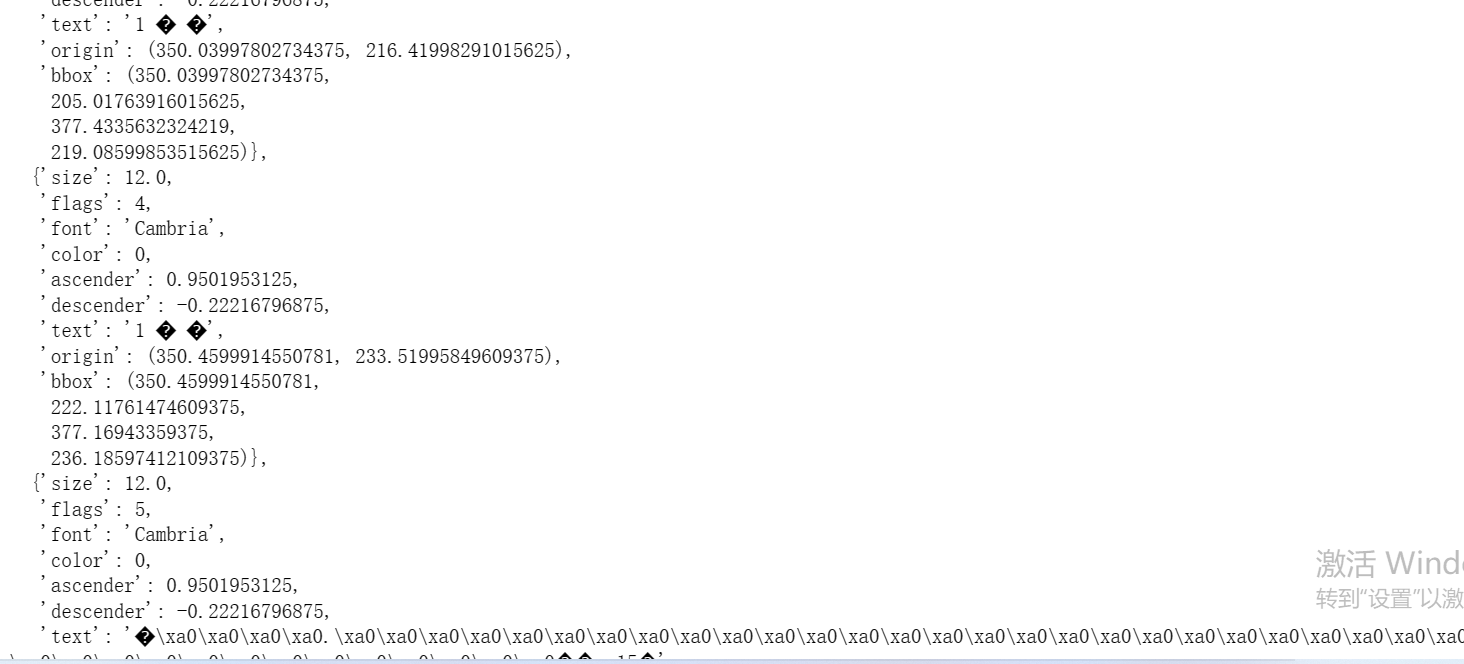

---------------------------------------

In [7]:
import fitz
def find_font_size_number_more_than_twice(path,main_text_font_size):
    """
    功能:统计font size出现次数>2的span
    思路:先获得全文span的font size再用Counter统计
    参数:
    返回值:
    """
    doc = fitz.open(path)
    record_most_account = []
    for i in range(doc.page_count):
        font_size,_,_ = statistics_of_font_size(doc[i])
        record_most_account = record_most_account+list(font_size)
    print("全文span总量:",len(record_most_account))
    order_list = sorted(dict(Counter(record_most_account)).items(),key=lambda x:x[0],reverse=1)
#     print(order_list)
    new_order_list=[]
    for i,j in dict(order_list).items():
        if i>main_text_font_size and j>=2:
            new_order_list.append((i,j))
    return dict(new_order_list),record_most_account
font_size_dict,record_most_account= find_font_size_number_more_than_twice(path,find_main_text_font_size(path))
print(font_size_dict)

def recovery_order_via_dict(dict_1,font_size_list):
    """
    功能:通过字典做font size的list筛选，恢复全局顺序
    参数:字典和font size list
    返回值:
        顺序list
    """
    recovery_list = []
    for i in font_size_list:
        if i in dict_1.keys():
            recovery_list.append(i)
    return recovery_list

R_list = recovery_order_via_dict(font_size_dict,record_most_account)
#去重判断是否满足树结构
new_list = []
for eleme in R_list:
    if eleme not in new_list:
        new_list.append(eleme)
new_list#去重后的list，每个元素可以视为表示一行


全文span总量: 46
全文频率最高span size: 9.754531860351562
全文span总量: 46
{21.947696685791016: 3, 17.070430755615234: 10}


[21.947696685791016, 17.070430755615234]

In [8]:

"""
什么叫做不满足树(大顶堆)结构？
1.在默认顺序下，有子节点比父亲节点大
2.节点个数为0
"""

'\n什么叫做不满足树(大顶堆)结构？\n1.在默认顺序下，有子节点比父亲节点大\n2.节点个数为0\n'

In [9]:
def start_from_first_biggest_number(lst):
    """
    功能:
        选择一个list中的最大值，返回对应索引
    参数:
        自带顺序的lst
    返回值:
        一个整数，表示lst中最大值的索引，如果lst为空或有多个最大值，返回-1
    """
    # 如果lst为空，返回-1
    if not lst:
        return -1
    # 初始化最大值和索引为第一个元素和0
    max_val = lst[0]
    max_idx = 0
    # 初始化一个标志，表示是否有多个最大值
    multiple = False
    # 遍历lst中除了第一个元素之外的其他元素
    for i in range(1, len(lst)):
        # 获取当前元素的值
        val = lst[i]
        # 如果当前元素的值大于最大值，更新最大值和索引，并将标志设为False
        if val > max_val:
            max_val = val
            max_idx = i
            multiple = False
        # 如果当前元素的值等于最大值，将标志设为True，表示有多个最大值
        elif val == max_val:
            multiple = True
    # 如果有多个最大值，返回-1，否则返回最大值的索引
    if multiple:
        return -1
    else:
        return max_idx

In [10]:


import random
# 定义一个函数，接受一个列表作为参数
def is_tree(lst):
    """
    功能:
        判断lst是否是否满足树结构
    参数:
    
    返回值:
    """
    
    return 

树结构的判断有很多细节要想，先放一下，因为目录的判断在文本分解中所占重要性一般
问题:
符合目录结构的树和一般的算法树有点不一样
       35   
  /      |     \
  22     25    24
 /  \    /  \   /
16 13.4 13.1 12 13.2

```
问题:
    大概率文章第一个font size不是一定是目录例如下面输出。取第一个最大值作为树的root比较合理

 [14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 14.0,
 35.9999885559082,
 35.9999885559082,
 30.0,
 30.0,
 13.979999542236328,
 25.979999542236328,
 25.979999542236328,
 25.979999542236328,
 25.979999542236328,
 16.020000457763672,
 16.020000457763672,
 13.979999542236328,
 13.999899864196777,
 13.999899864196777,
 13.999899864196777,
 13.999899864196777]
```

In [11]:
def find_TOC(path):
    """
    功能:
        没有TOC情况下找目录
        1.所有 font size > 正文的 font size，并且出现次数 >= 2 的认为是目录(先统计目前哪些span的font size出现次数超过2次)
        2.按照 font size 从大到小排序，是否能形成一颗完备的树
    参数:
        
    返回值:
        
    """
    doc =fitz.open(path)
    main_text_font_size= find_main_text_font_size()
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        for block in text_dict["blocks"]:  # 遍历每个文本块
            if block["type"] == 0:  # 如果是文字类型
                for line in block["lines"]:  # 遍历每一行
                    for span in line["spans"]:  # 遍历每个span
#                         print(span["size"])
                        if span["size"]>main_text_font_size:
                            per_page_main_text.append(span)
                
        all_page_main_text.append(per_page_main_text)
    return all_page_main_text
# if doc.get_toc() != []:
#     print(doc.get_toc())
# else:    


-------------------------------------

找段落  

根据 Block, Line, Span 找到 Page 的左右边界  
根据 连续 Span xxbox 位置关系和 Block 边界的关系，判断段落的结束和下一段开始  

In [12]:
def find_border_of_page(path):
    """
    思路:
我要看一段文本是不是段落:
1.边界
2.文本的开始和结束

    """
    doc = fitz.open(path)
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        for block in text_dict["blocks"]:  # 遍历每个文本块
            if block["type"] == 0:  # 如果是文字类型
                print(block)
                break
        break
#                 for line in block["lines"]:  # 遍历每一行
#                     for span in line["spans"]:  # 遍历每个span
#                         print(span["bbox"])
def judge_paragraph_start_and_end():
    pass
find_border_of_page(path)

{'number': 0, 'type': 0, 'bbox': (75.52161407470703, 69.13951110839844, 332.57098388671875, 81.09500885009766), 'lines': [{'spans': [{'size': 8.779078483581543, 'flags': 16, 'font': 'OpenSans-Bold', 'color': 4227779, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'AI could create a  perfect storm of  climate misinformation', 'origin': (75.52161407470703, 78.52301025390625), 'bbox': (75.52161407470703, 69.13951110839844, 332.57098388671875, 81.09500885009766)}], 'wmode': 0, 'dir': (1.0, 0.0), 'bbox': (75.52161407470703, 69.13951110839844, 332.57098388671875, 81.09500885009766)}]}


```

任务:
拿到正文span list
拿到分界span list
    具体:在block中筛选--离block_x远，span_x1 > next span_x0 and span_y1>next span_y0

实现如下伪代码:
paragraph =[]
first_index =0
for span,span_index in zip(span_list,range(len(span_list))):
    if span in 分界span_list:
        paragraph.append(span_list[first_index:span_index+1])#+1因为分界span在段落末尾，属于该段落也要包括
        first_index =span_index
```

In [13]:
# 拿到正文span list
main_text_font_size = find_main_text_font_size(path)
main_text_span= find_main_text(path,main_text_font_size) 
# print(main_text_span)

全文span总量: 46
全文频率最高span size: 9.754531860351562
全文span总量: 46
全文频率最高span size: 9.754531860351562


```
'size': 12.0, 'flags': 4, 'font': 'TimesNewRomanPSMT', 'color': 0, 'ascender': 0.89111328125, 'descender': -0.21630859375, 'text': ' ', 'origin': (306.0, 736.6799926757812), 'bbox': (306.0, 725.9866333007812, 309.0, 739.2756958007812)}, {'size': 12.0, 'flags': 4, 'font': 'TimesNewRomanPSMT', 'color': 0, 'ascender': 0.89111328125, 'descender': -0.21630859375, 'text': ' ', 'origin': (79.20001220703125, 751.8599853515625), 'bbox': (79.20001220703125, 741.1666259765625, 82.20001220703125, 754.4556884765625)}, {'size': 12.0, 'flags': 4, 'font': 'TimesNewRomanPSMT', 'color': 0, 'ascender': 0.89111328125, 'descender': -0.21630859375, 'text': ' ', 'origin': (79.19999694824219, 624.719970703125), 'bbox': (79.19999694824219, 614.026611328125, 82.19999694824219, 627.315673828125)},
```

In [14]:
def test_1(span_list):
    """
    可视化正文提取情况
    """
    doc = fitz.open(path)
    for i in span_list:
        for j in i:
            print(j)
            page = doc[j["page"]]
            rect = fitz.Rect(j["bbox"])
            page.draw_rect(rect)
    doc.save("检测全文span分割情况_基于TEST.pdf.pdf")
test_1(main_text_span)

{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': '\xa0', 'origin': (75.52161407470703, 179.06973266601562), 'bbox': (75.52161407470703, 168.6436309814453, 78.05550384521484, 181.92750549316406), 'page': 0}
{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'We are in the midst of a transformation of the digital news ecosystem.  The expansion of online ', 'origin': (75.52161407470703, 320.13525390625), 'bbox': (75.52161407470703, 309.7091369628906, 510.5728759765625, 322.9930419921875), 'page': 0}
{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'social networks, the influence of recommender  systems, increased automation, and new ', 'origin': (75.52161407470703, 335.892578125), 'bbox': (75.521614074

In [15]:
doc = fitz.open(path)
for i in range(len(main_text_span)):#每一页
    for j in range(len(main_text_span[i])):#每一页的每一个span
        if j+1==len(main_text_span[i])-1:
            break
        else:
            if main_text_span[i][j]==[]:
                continue
            else:
#                 print(main_text_span[i][j]["bbox"])
                if main_text_span[i][j]["bbox"][2]>main_text_span[i][j+1]["bbox"][0] and main_text_span[i][j]["bbox"][3]>main_text_span[i][j+1]["bbox"][1]:
                    print(main_text_span[i][j])
#                     pdf_draw(main_text_span[i][j]["bbox"],path,main_text_span[i][j]["page"])
                    page = doc[main_text_span[i][j]["page"]]
                    rect = fitz.Rect(main_text_span[i][j]["bbox"])
                    page.draw_rect(rect)


{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'Our ', 'origin': (75.52161407470703, 491.2147521972656), 'bbox': (75.52161407470703, 480.78863525390625, 95.62342071533203, 494.0725402832031), 'page': 0}
{'size': 9.754531860351562, 'flags': 6, 'font': 'OpenSans-Italic', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'living', 'origin': (95.61688995361328, 491.2147521972656), 'bbox': (95.61688995361328, 480.78863525390625, 118.07160186767578, 494.0725402832031), 'page': 0}
{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 3355443, 'ascender': 1.06884765625, 'descender': -0.29296875, 'text': 'turbulence, ', 'origin': (75.52161407470703, 522.7293701171875), 'bbox': (75.52161407470703, 512.3032836914062, 129.87159729003906, 525.587158203125), 'page': 0}
{'size': 9.754531860351562, 'flags': 0, 'font': 'OpenSans-Regular', 'color': 33554

In [16]:
# 拿到分界span list（在main span list中筛选）

def get_split_span(path):
    doc = fitz.open(path)
    for i in range(doc.page_count):
        page = doc[i]
        text_dict = page.get_text("dict")  # 获取文本信息字典
        
        per_page_main_text = []
        for block in text_dict["blocks"]:  # 遍历每个文本块
            print(block["bbox"])
            
#             if block["type"] == 0:  # 如果是文字类型
#                 for line in block["lines"]:  # 遍历每一行
#                     for span in line["spans"]:  # 遍历每个span
#                         print(span["bbox"])
get_split_span(path)

(75.52161407470703, 69.13951110839844, 332.57098388671875, 81.09500885009766)
(93.07273864746094, 83.39613342285156, 329.0316467285156, 95.35163116455078)
(93.07273864746094, 96.90241241455078, 371.3280029296875, 108.85791015625)
(93.07273864746094, 111.1590347290039, 228.5438232421875, 123.11453247070312)
(93.07273864746094, 125.4156494140625, 306.29949951171875, 137.3711395263672)
(75.52161407470703, 168.6436309814453, 78.05550384521484, 181.92750549316406)
(75.52161407470703, 190.8773651123047, 441.9677429199219, 247.02830505371094)
(519.7279663085938, 190.8773651123047, 525.42919921875, 220.76609802246094)
(75.52161407470703, 254.61758422851562, 428.7270812988281, 298.8741760253906)
(519.7279663085938, 254.61758422851562, 524.1622924804688, 277.8643798828125)
(75.52161407470703, 309.7091369628906, 510.5728759765625, 322.9930419921875)
(75.52161407470703, 325.4664611816406, 482.1182556152344, 338.7503662109375)
(75.52161407470703, 340.47344970703125, 463.6995544433594, 353.757354736